# Transformer Fine-Tuning for Arabic QA Classification
This notebook fine-tunes AraBERT across the original and preprocessed datasets, then compares results.

## 1. Set Up Notebook Environment

In [3]:
import os
import warnings
import glob
import random
import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from IPython.display import display
from datasets import Dataset, ClassLabel
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
# Suppress standard warnings but leave Hugging Face loggers alone
warnings.filterwarnings("ignore")

In [4]:
SEED = 42
TEST_SIZE = 0.2
RANDOM_STATE = 42

DATASET_ROOT = "."
PREPROCESSED_DIR = os.path.join(DATASET_ROOT, "/kaggle/input/datasets/yazanalatout/aafaq-dataset/preprocessed datasets")
ORIGINAL_DATASET = os.path.join(DATASET_ROOT, "/kaggle/input/datasets/yazanalatout/aafaq-dataset/AAFAQ_Dataset.csv")
OUTPUT_DIR = os.path.join(DATASET_ROOT, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 2. Load or Generate Input Data

In [5]:
def build_dataset_registry():
    registry = {"Original (raw)": ORIGINAL_DATASET}
    if os.path.isdir(PREPROCESSED_DIR):
        for path in sorted(glob.glob(os.path.join(PREPROCESSED_DIR, "*.csv"))):
            base = os.path.splitext(os.path.basename(path))[0]
            display = base.replace("_", " ")
            registry[display] = path
    return registry

def load_dataset(path):
    df = pd.read_csv(path)
    required = {"QuestionText", "Category"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns {missing} in {path}")
    df = df.dropna(subset=["QuestionText", "Category"]).reset_index(drop=True)
    df["QuestionText"] = df["QuestionText"].astype(str).str.strip()
    df = df[df["QuestionText"].str.len() > 0].reset_index(drop=True)
    return df

DATASET_REGISTRY = build_dataset_registry()
datasets = {name: load_dataset(path) for name, path in DATASET_REGISTRY.items()}
pd.DataFrame(
    [{"Dataset": k, "Rows": v.shape[0], "Categories": v["Category"].nunique()} for k, v in datasets.items()]
).sort_values("Rows", ascending=False)

,Dataset,Rows,Categories
0,Original (raw),5009,17
1,pyarabic aggressive preprocessed,5009,17
2,pyarabic hamza only preprocessed,5009,17
3,pyarabic hamza tashkeel preprocessed,5009,17
4,pyarabic punctuation only preprocessed,5009,17
5,pyarabic tashkeel tatweel preprocessed,5009,17
6,regex aggressive preprocessed,5009,17


## 3. Implement Core Processing Logic


🚀 NOW TRAINING ON: Original (raw)



Casting the dataset:   0%|          | 0/5009 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/1002 [00:00<?, ? examples/s]

The following layers were not sharded: bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.embeddings.LayerNorm.weight, classifier.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.output.dense.weight, bert.pooler.dense.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.attention.self.key.bias, bert.pooler.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.attention.self.value.weight, bert.embeddings.word_embeddings.weight, classifier.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.attention.self.value.bias,

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

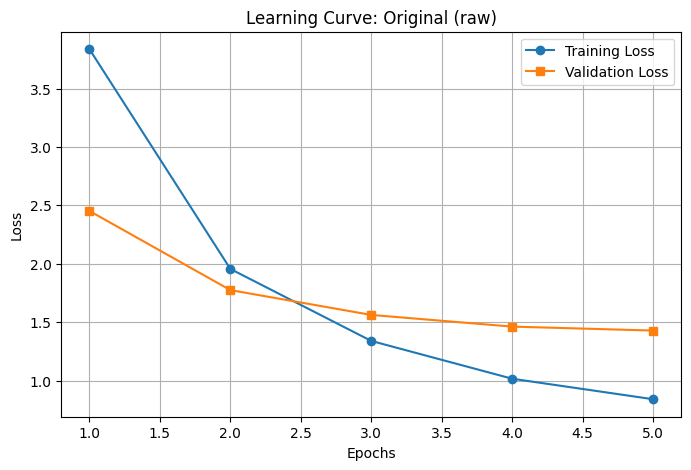


🚀 NOW TRAINING ON: pyarabic aggressive preprocessed



Casting the dataset:   0%|          | 0/5009 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/1002 [00:00<?, ? examples/s]

The following layers were not sharded: bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.embeddings.LayerNorm.weight, classifier.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.output.dense.weight, bert.pooler.dense.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.attention.self.key.bias, bert.pooler.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.attention.self.value.weight, bert.embeddings.word_embeddings.weight, classifier.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.attention.self.value.bias,

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

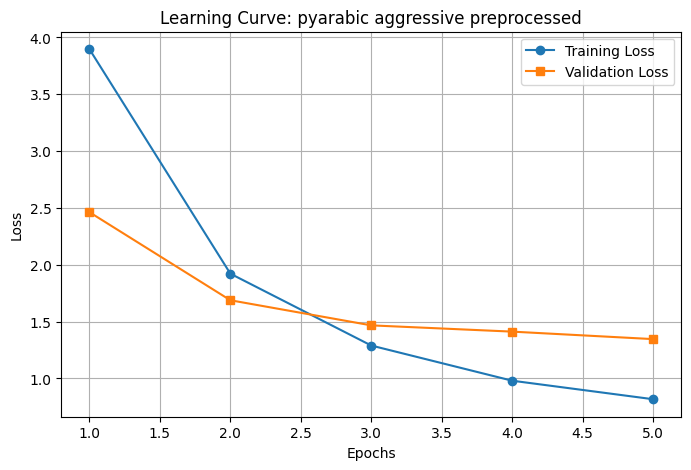


🚀 NOW TRAINING ON: pyarabic hamza only preprocessed



Casting the dataset:   0%|          | 0/5009 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/1002 [00:00<?, ? examples/s]

The following layers were not sharded: bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.embeddings.LayerNorm.weight, classifier.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.output.dense.weight, bert.pooler.dense.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.attention.self.key.bias, bert.pooler.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.attention.self.value.weight, bert.embeddings.word_embeddings.weight, classifier.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.attention.self.value.bias,

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

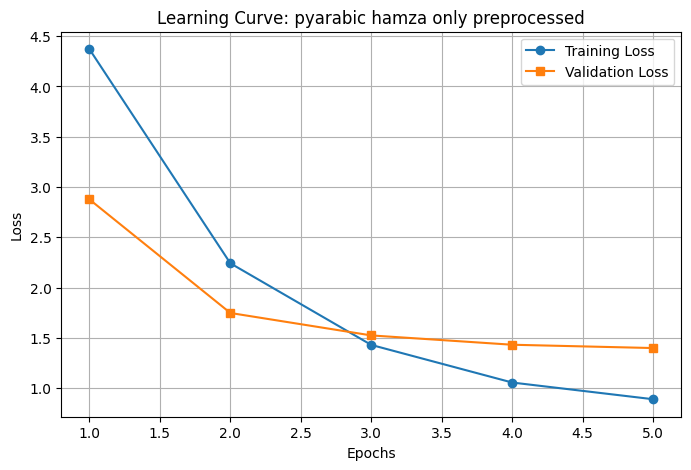


🚀 NOW TRAINING ON: pyarabic hamza tashkeel preprocessed



Casting the dataset:   0%|          | 0/5009 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/1002 [00:00<?, ? examples/s]

The following layers were not sharded: bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.embeddings.LayerNorm.weight, classifier.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.output.dense.weight, bert.pooler.dense.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.attention.self.key.bias, bert.pooler.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.attention.self.value.weight, bert.embeddings.word_embeddings.weight, classifier.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.attention.self.value.bias,

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

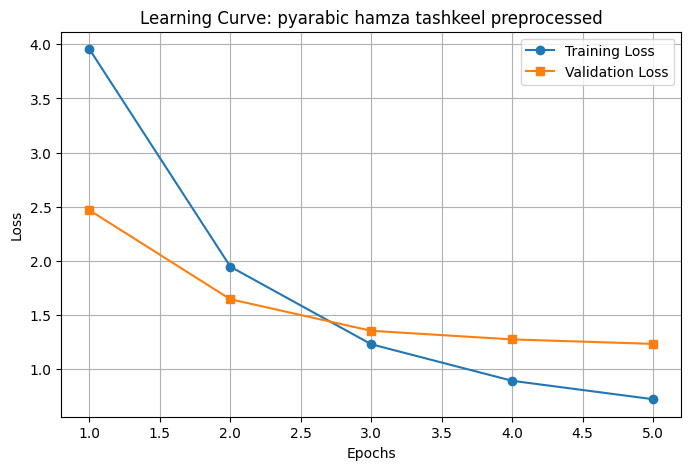


🚀 NOW TRAINING ON: pyarabic punctuation only preprocessed



Casting the dataset:   0%|          | 0/5009 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/1002 [00:00<?, ? examples/s]

The following layers were not sharded: bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.embeddings.LayerNorm.weight, classifier.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.output.dense.weight, bert.pooler.dense.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.attention.self.key.bias, bert.pooler.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.attention.self.value.weight, bert.embeddings.word_embeddings.weight, classifier.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.attention.self.value.bias,

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

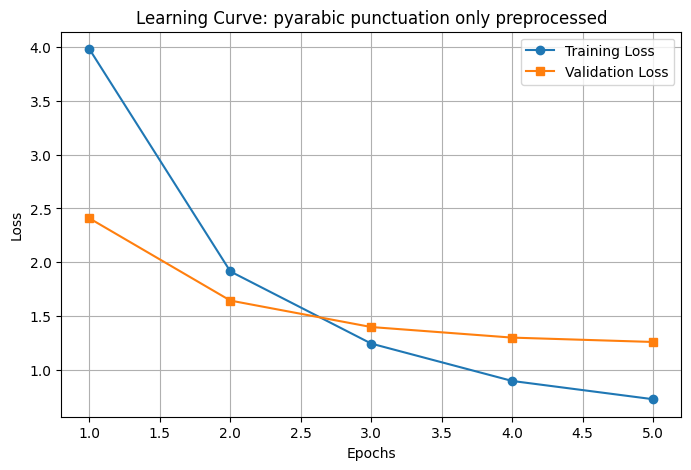


🚀 NOW TRAINING ON: pyarabic tashkeel tatweel preprocessed



Casting the dataset:   0%|          | 0/5009 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/1002 [00:00<?, ? examples/s]

The following layers were not sharded: bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.embeddings.LayerNorm.weight, classifier.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.output.dense.weight, bert.pooler.dense.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.attention.self.key.bias, bert.pooler.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.attention.self.value.weight, bert.embeddings.word_embeddings.weight, classifier.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.attention.self.value.bias,

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

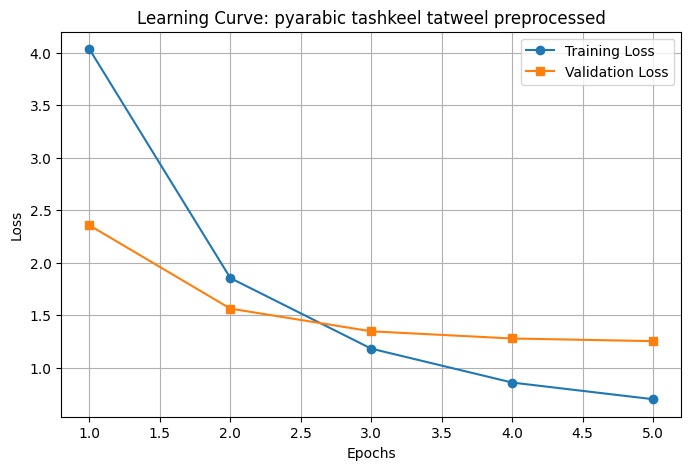


🚀 NOW TRAINING ON: regex aggressive preprocessed



Casting the dataset:   0%|          | 0/5009 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/1002 [00:00<?, ? examples/s]

The following layers were not sharded: bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.query.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.embeddings.LayerNorm.weight, classifier.bias, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, bert.encoder.layer.*.output.dense.weight, bert.pooler.dense.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.attention.self.key.bias, bert.pooler.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.attention.self.value.weight, bert.embeddings.word_embeddings.weight, classifier.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.attention.self.value.bias,

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

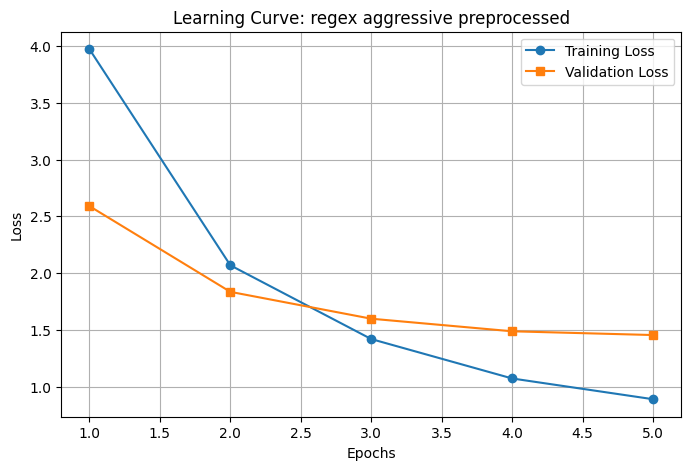

,Dataset,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,Original (raw),1.428038,0.793413,0.689260,0.630094,0.641351,5.4365,184.310,5.886
1,pyarabic aggressive preprocessed,1.411277,0.798403,0.703412,0.697049,0.696204,5.4463,183.977,5.876
2,pyarabic hamza only preprocessed,1.397756,0.801397,0.711326,0.665702,0.679230,5.4625,183.433,5.858
3,pyarabic hamza tashkeel preprocessed,1.233574,0.825349,0.795920,0.738069,0.741608,5.4333,184.418,5.890
4,pyarabic punctuation only preprocessed,1.296597,0.820359,0.784256,0.732681,0.753214,5.4388,184.232,5.884
5,pyarabic tashkeel tatweel preprocessed,1.253512,0.825349,0.796322,0.748430,0.760467,5.4705,183.165,5.850
6,regex aggressive preprocessed,1.456773,0.799401,0.761940,0.670922,0.674128,5.4592,183.543,5.862


In [7]:
# Suppress all warnings
import logging

# Kill the unauthenticated Hub warning
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

# Kill the "UNEXPECTED/MISSING" model weight load reports
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

def prepare_hf_dataset(df, label2id):
    work = df.copy()
    work["label"] = work["Category"].map(label2id)
    work = work.rename(columns={"QuestionText": "text"})
    dataset = Dataset.from_pandas(work[["text", "label"]])
    
    # Cast the label column to ClassLabel
    labels_list = list(label2id.keys())
    dataset = dataset.cast_column("label", ClassLabel(names=labels_list))
    
    dataset = dataset.train_test_split(
        test_size=TEST_SIZE,
        seed=SEED,
        stratify_by_column="label",
    )
    tokenized = dataset.map(tokenize_function, batched=True, remove_columns=["text"])
    tokenized = tokenized.rename_column("label", "labels")
    tokenized.set_format("torch")
    return tokenized

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
    }

def plot_learning_curves(log_history, dataset_name):
    train_loss = [x["loss"] for x in log_history if "loss" in x and "epoch" in x]
    train_epochs = [x["epoch"] for x in log_history if "loss" in x and "epoch" in x]
    
    eval_loss = [x["eval_loss"] for x in log_history if "eval_loss" in x and "epoch" in x]
    eval_epochs = [x["epoch"] for x in log_history if "eval_loss" in x and "epoch" in x]

    plt.figure(figsize=(8, 5))
    if train_loss:
        plt.plot(train_epochs, train_loss, label="Training Loss", marker="o")
    if eval_loss:
        plt.plot(eval_epochs, eval_loss, label="Validation Loss", marker="s")
        
    plt.title(f"Learning Curve: {dataset_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def train_evaluate_dataset(dataset_name, df):
    print(f"\n======================================")
    print(f"🚀 NOW TRAINING ON: {dataset_name}")
    print(f"======================================\n")

    labels = sorted(df["Category"].unique())
    label2id = {label: i for i, label in enumerate(labels)}
    id2label = {i: label for label, i in label2id.items()}
    tokenized = prepare_hf_dataset(df, label2id)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(labels),
        label2id=label2id,
        id2label=id2label,
        ignore_mismatched_sizes=True
    )
    
    out_dir = os.path.join(OUTPUT_DIR, f"transformer_{dataset_name.replace(' ', '_')}")
    args = TrainingArguments(
        output_dir=out_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        logging_strategy="epoch",
        save_total_limit=1,
        seed=SEED,
        report_to="none" 
    )
    
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        processing_class=tokenizer, 
        compute_metrics=compute_metrics,
    )
    
    trainer.train()
    
    plot_learning_curves(trainer.state.log_history, dataset_name)
    
    metrics = trainer.evaluate()
    result = {"Dataset": dataset_name}
    result.update({k: float(v) for k, v in metrics.items() if k.startswith("eval_")})
    return result

def run_transformer_experiments(datasets):
    results = []
    for name, df in datasets.items():
        results.append(train_evaluate_dataset(name, df))
    results_df = pd.DataFrame(results)
    results_path = os.path.join(OUTPUT_DIR, "transformer_results.csv")
    results_df.to_csv(results_path, index=False)
    return results_df

RUN_TRAINING = True
results_df = pd.DataFrame()
if RUN_TRAINING:
    results_df = run_transformer_experiments(datasets)
    display(results_df) # This displays the dataframe in your notebook
else:
    print("Set RUN_TRAINING=True to run fine-tuning.")

## 4. Visualize or Inspect Results

,Dataset,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second
3,pyarabic hamza tashkeel preprocessed,1.233574,0.825349,0.795920,0.738069,0.741608,5.4333,184.418,5.890
5,pyarabic tashkeel tatweel preprocessed,1.253512,0.825349,0.796322,0.748430,0.760467,5.4705,183.165,5.850
4,pyarabic punctuation only preprocessed,1.296597,0.820359,0.784256,0.732681,0.753214,5.4388,184.232,5.884
2,pyarabic hamza only preprocessed,1.397756,0.801397,0.711326,0.665702,0.679230,5.4625,183.433,5.858
1,pyarabic aggressive preprocessed,1.411277,0.798403,0.703412,0.697049,0.696204,5.4463,183.977,5.876
0,Original (raw),1.428038,0.793413,0.689260,0.630094,0.641351,5.4365,184.310,5.886
6,regex aggressive preprocessed,1.456773,0.799401,0.761940,0.670922,0.674128,5.4592,183.543,5.862


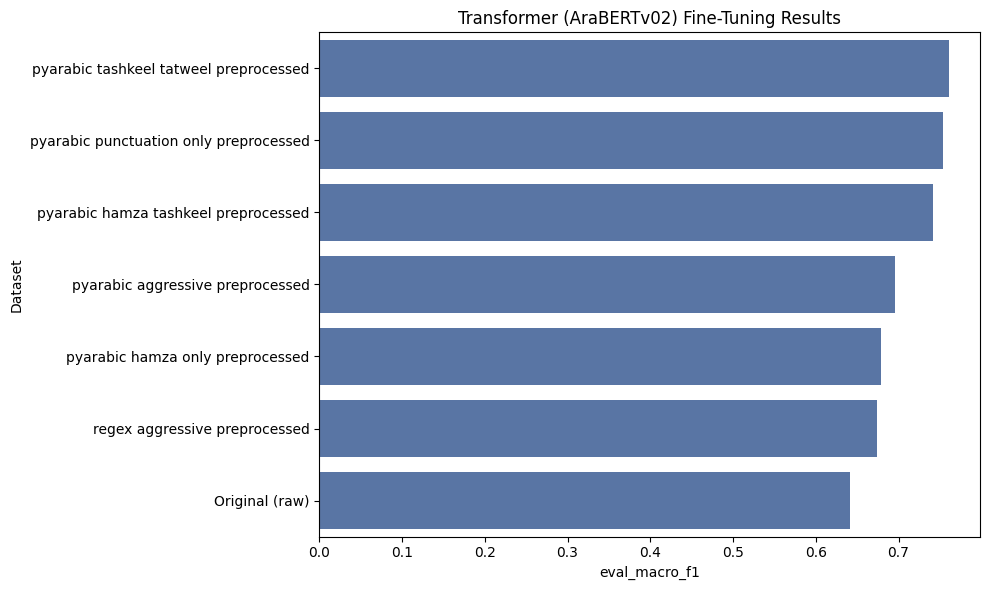

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

if not results_df.empty:
    display(results_df.sort_values(by=['eval_loss']))
    metric_col = "eval_macro_f1" if "eval_macro_f1" in results_df.columns else None
    if metric_col:
        plt.figure(figsize=(10, 6))
        sns.barplot(data=results_df.sort_values(metric_col, ascending=False), x=metric_col, y="Dataset", color="#4C72B0")
        plt.title("Transformer (AraBERTv02) Fine-Tuning Results")
        plt.tight_layout()
        plt.show()
else:
    print("No results yet. Run training to populate results_df.")

In [13]:
import plotly.express as px

fig = px.scatter(
    results_df, 
    x="eval_loss", 
    y="eval_macro_f1", 
    color="Dataset", 
    size="eval_accuracy", 
    hover_data=["eval_macro_precision", "eval_macro_recall"],
    title="Validation Loss vs. Macro F1 (Bubble Size = Accuracy)")
fig.show()